### PROYECTO: Dinámica de pérdida forestal en categorías de ordenamiento
Área de estudio: Provincia de Córdoba

OBJETIVO:
Analizar la evolución temporal de la pérdida de superficie forestal en distintas categorías de ordenamiento territorial:
   - Categoría I
   - Categoría II
   - Categoría III
   - Sin categoría

 El análisis se realiza a dos escalas espaciales:
   1. Provincial
   2. Departamental

In [1]:
# 1. CARGA DE DATOS

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print("librerias ok")


librerias ok


In [2]:
# Se define el directorio de trabajo donde se encuentra la base
path = "D:/Josefina/Proyectos/Bosques/data/perdida_forestalesOtras_categorias.csv"

# Se carga el dataset con pérdidas forestales en otras categorías
# encoding="latin1" se utiliza para evitar problemas con tildes
data = pd.read_csv(path, encoding="latin1")

In [5]:
# 2. ANÁLISIS A ESCALA PROVINCIAL

# Se filtran únicamente los registros con resolución espacial provincial
data_provincial = data[data["resolucion_espacial"] == "provincial"].copy()

# Exploración básica del dataset
print(data_provincial["sitio"].unique())
print(data_provincial.columns)


<StringArray>
[       'Buenos Aires',           'Catamarca',               'Chaco',
              'Chubut',             'Córdoba',          'Corrientes',
          'Entre Rios',             'Formosa',               'Jujuy',
            'La Pampa',            'La Rioja',             'Mendoza',
            'Misiones',             'Neuquén',           'Río Negro',
               'Salta',            'San Juan',            'San Luis',
          'Santa Cruz',            'Santa Fe', 'Santiago del Estero',
    'Tierra del Fuego',             'Tucumán']
Length: 23, dtype: str
Index(['resolucion_espacial', 'sitio', 'year', 'year_2',
       'perdida_forestales_otras_cat_I ', 'perdida_forestales_otras_cat_II ',
       'perdida_forestales_otras_cat_III', 'perdida_forestales_otras_cat_Scat',
       'perdida_forestales_otras_cat_total', 'perdida_forestales_cat_I ',
       'perdida_forestales_cat_II ', 'perdida_forestales_cat_III ',
       'perdida_forestales_cat_Scat', 'perdida_forestales_cat_total',

In [ ]:
#Hay un error en los nombres de las columnas, hay un espacio al final, lo solucionamos asi y volvemos a correr el codigo
# print(data_provincial.columns.tolist())
data_provincial.columns = data_provincial.columns.str.strip()

In [ ]:
# 2.1 Transformación a formato largo (long format)
#
# Se pasan las columnas de categorías a una sola columna llamada "categoria",
# lo que permite graficar y analizar dinámicas comparativas entre categorías.

cols_categorias = [
    "perdida_forestales_otras_cat_I",
    "perdida_forestales_otras_cat_II",
    "perdida_forestales_otras_cat_III",
    "perdida_forestales_otras_cat_Scat"
]

data_long = data_provincial.melt(
    id_vars=[col for col in data_provincial.columns if col not in cols_categorias],
    value_vars=cols_categorias,
    var_name="categoria",
    value_name="hectareas"
)

# Re-codificación de nombres de categorías
data_long["categoria"] = data_long["categoria"].replace({
    "perdida_forestales_otras_cat_I": "Cat I",
    "perdida_forestales_otras_cat_II": "Cat II",
    "perdida_forestales_otras_cat_III": "Cat III",
    "perdida_forestales_otras_cat_Scat": "Sin categoría"
})


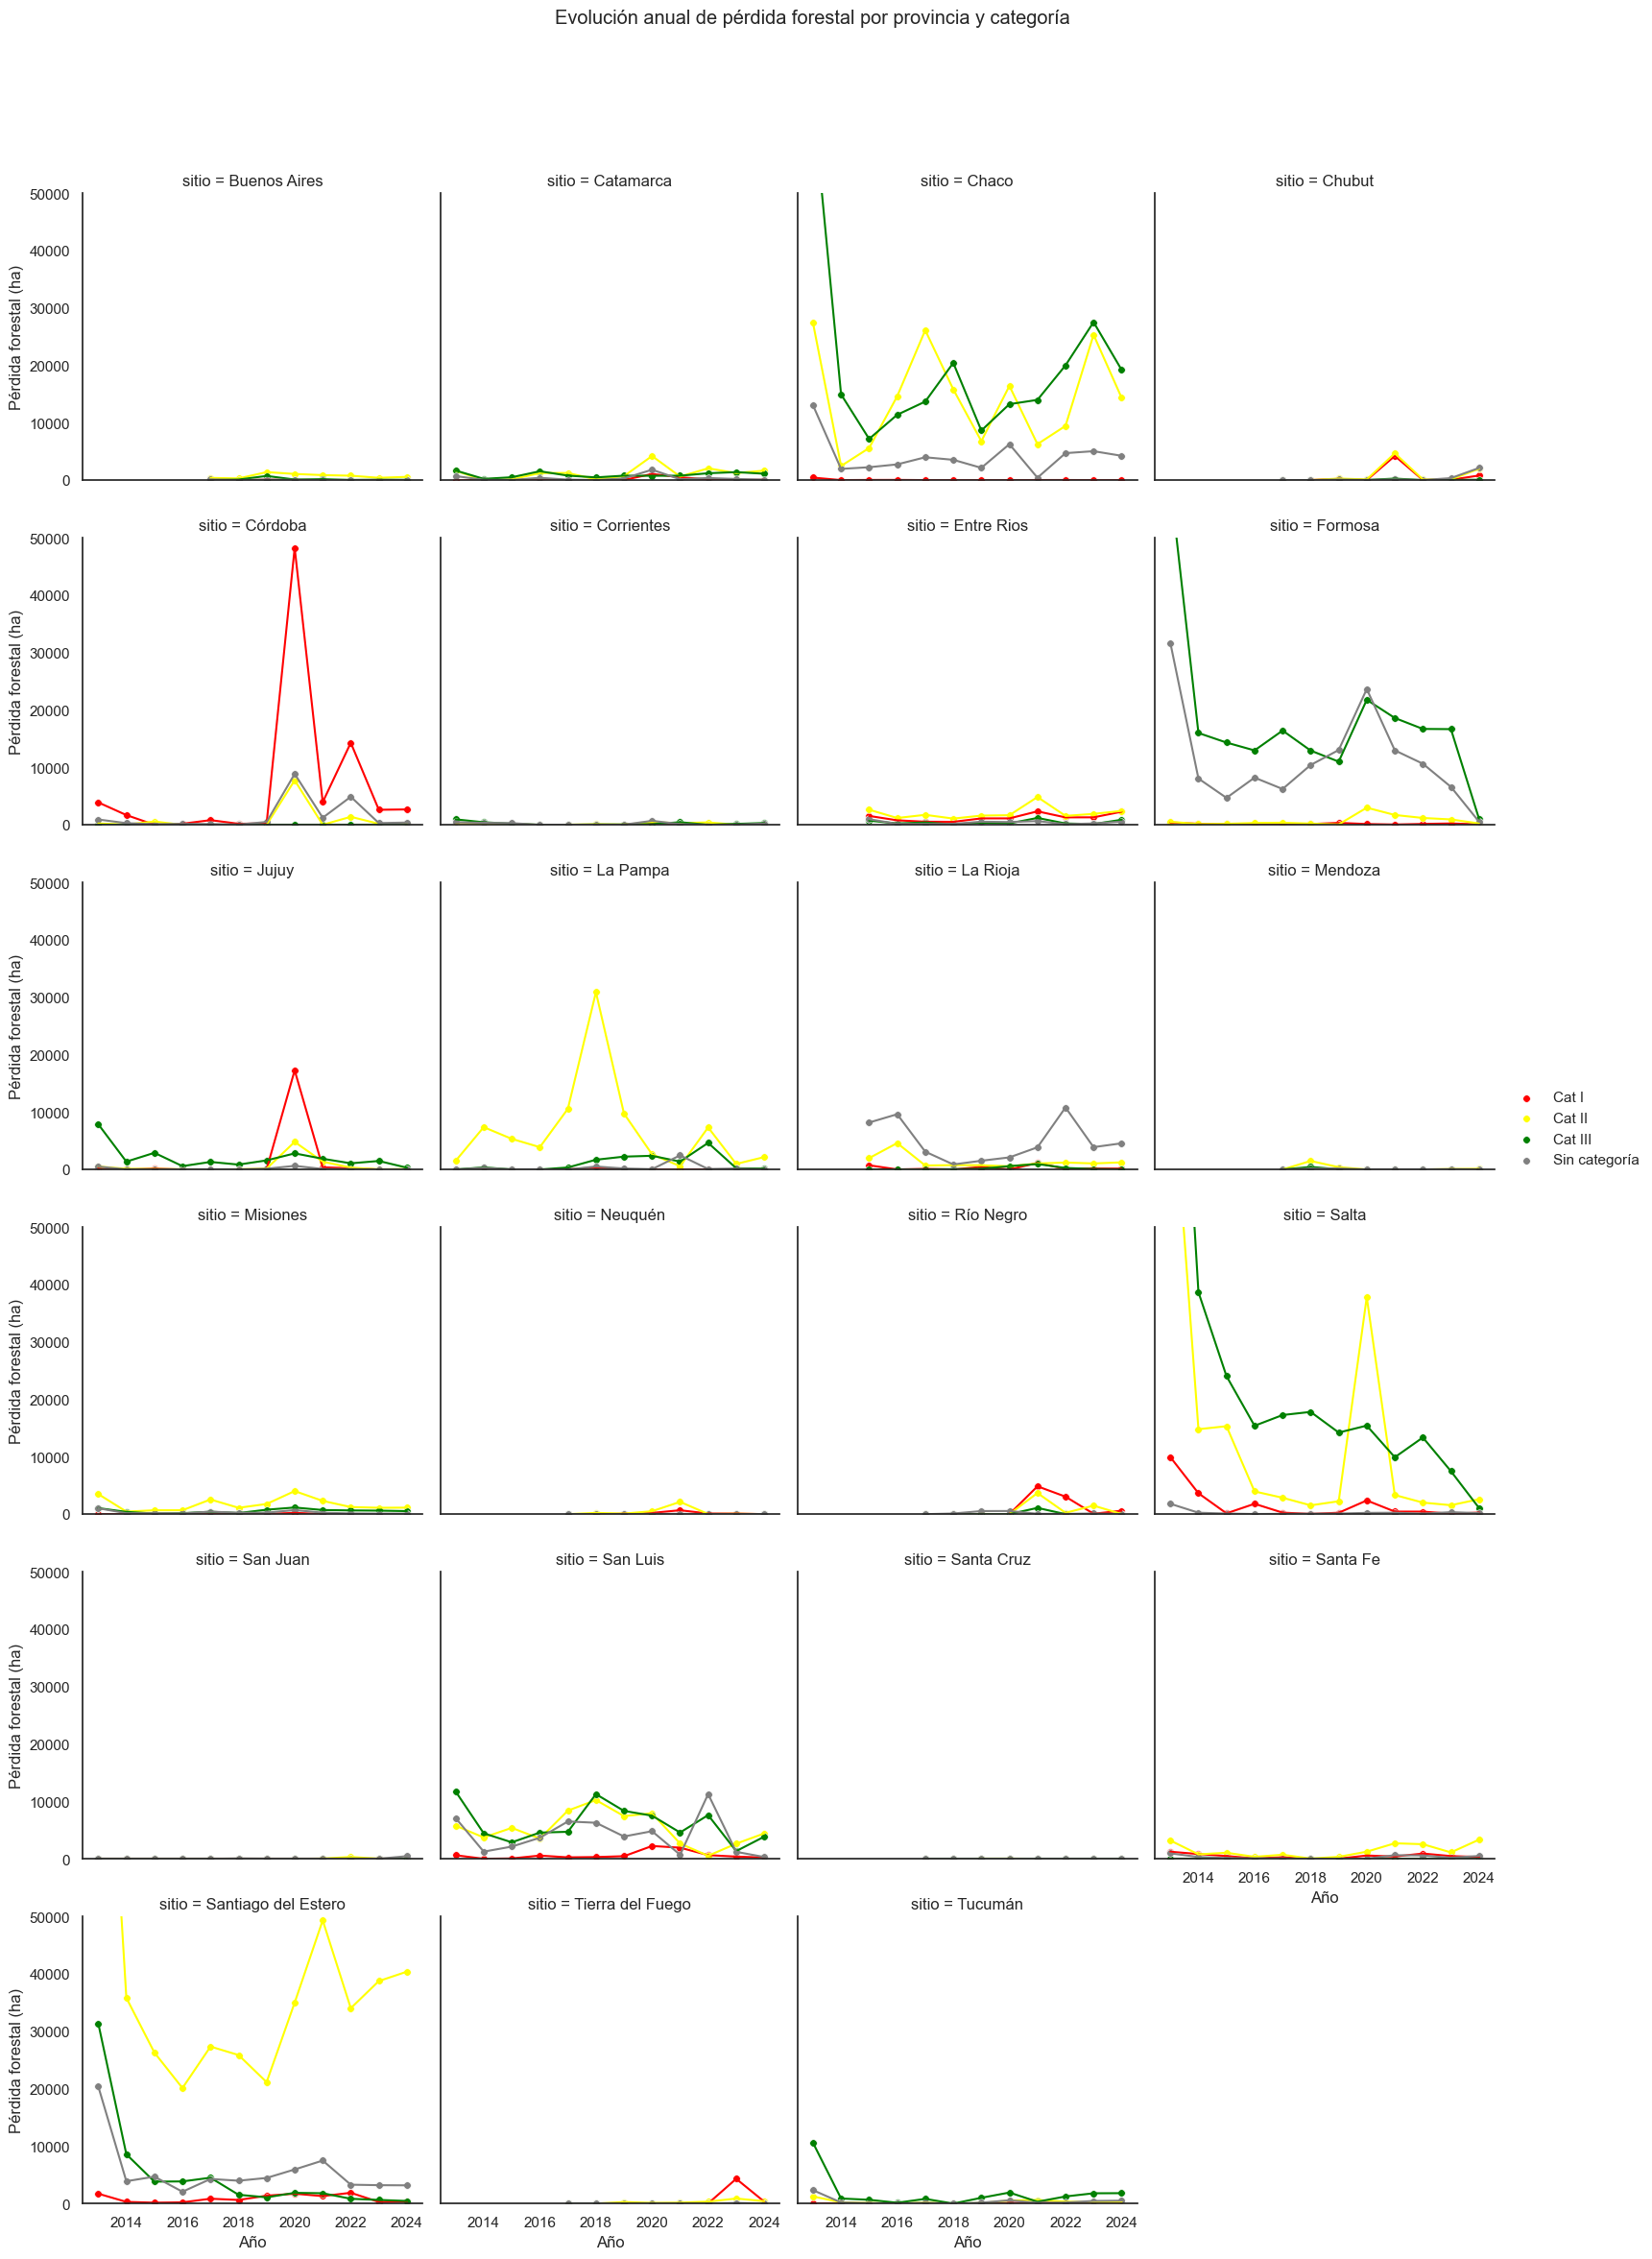

In [11]:
# 2.2 Visualización: evolución anual de pérdida forestal (escala provincial)

sns.set_theme(style="white")

g = sns.FacetGrid(
    data_long,
    col="sitio",
    col_wrap=4,
    sharey=True,
    height=4,
    hue="categoria",
    palette={
        "Cat I": "red",
        "Cat II": "yellow",
        "Cat III": "green",
        "Sin categoría": "grey"
    }
)

g.map_dataframe(sns.lineplot, x="year_2", y="hectareas")
g.map_dataframe(sns.scatterplot, x="year_2", y="hectareas", s=30)

g.set_axis_labels("Año", "Pérdida forestal (ha)")
g.add_legend(title="")

for ax in g.axes.flatten():
    ax.set_ylim(0, 50000)

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Evolución anual de pérdida forestal por provincia y categoría")

plt.show()

['Buenos Aires', 'Calamuchita', 'Catamarca', 'Chaco', 'Chubut', 'Colón', 'Corrientes', 'Cruz del Eje', 'Córdoba', 'Entre Rios', 'Formosa', 'General Roca', 'General San Martín', 'Ischilín', 'Jujuy', 'Juárez Celman', 'La Pampa', 'La Rioja', 'Mendoza', 'Minas', 'Misiones', 'Neuquén', 'Pocho', 'Punilla', 'Río Cuarto', 'Río Negro', 'Río Primero', 'Río Seco', 'Río Segundo', 'Salta', 'San Alberto', 'San Javier', 'San Juan', 'San Justo', 'San Luis', 'Santa Cruz', 'Santa Fe', 'Santa María', 'Santiago del Estero', 'Sobremonte', 'Tercero Arriba', 'Tierra del Fuego', 'Totoral', 'Tucumán', 'Tulumba', 'Unión']


<StringArray>
[      'Cruz del Eje',        'San Alberto',            'Punilla',
           'Río Seco',              'Pocho',            'Tulumba',
              'Minas',         'Río Cuarto',           'Ischilín',
         'Sobremonte',        'Santa María',         'San Javier',
              'Colón',        'Río Primero',            'Totoral',
        'Calamuchita',          'San Justo',       'General Roca',
      'Juárez Celman',        'Río Segundo',     'Tercero Arriba',
              'Unión', 'General San Martín']
Length: 23, dtype: str
Index(['resolucion_espacial', 'sitio', 'year', 'year_2',
       'perdida_forestales_otras_cat_I ', 'perdida_forestales_otras_cat_II ',
       'perdida_forestales_otras_cat_III', 'perdida_forestales_otras_cat_Scat',
       'perdida_forestales_otras_cat_total', 'perdida_forestales_cat_I ',
       'perdida_forestales_cat_II ', 'perdida_forestales_cat_III ',
       'perdida_forestales_cat_Scat', 'perdida_forestales_cat_total',
       'perdida_otras_

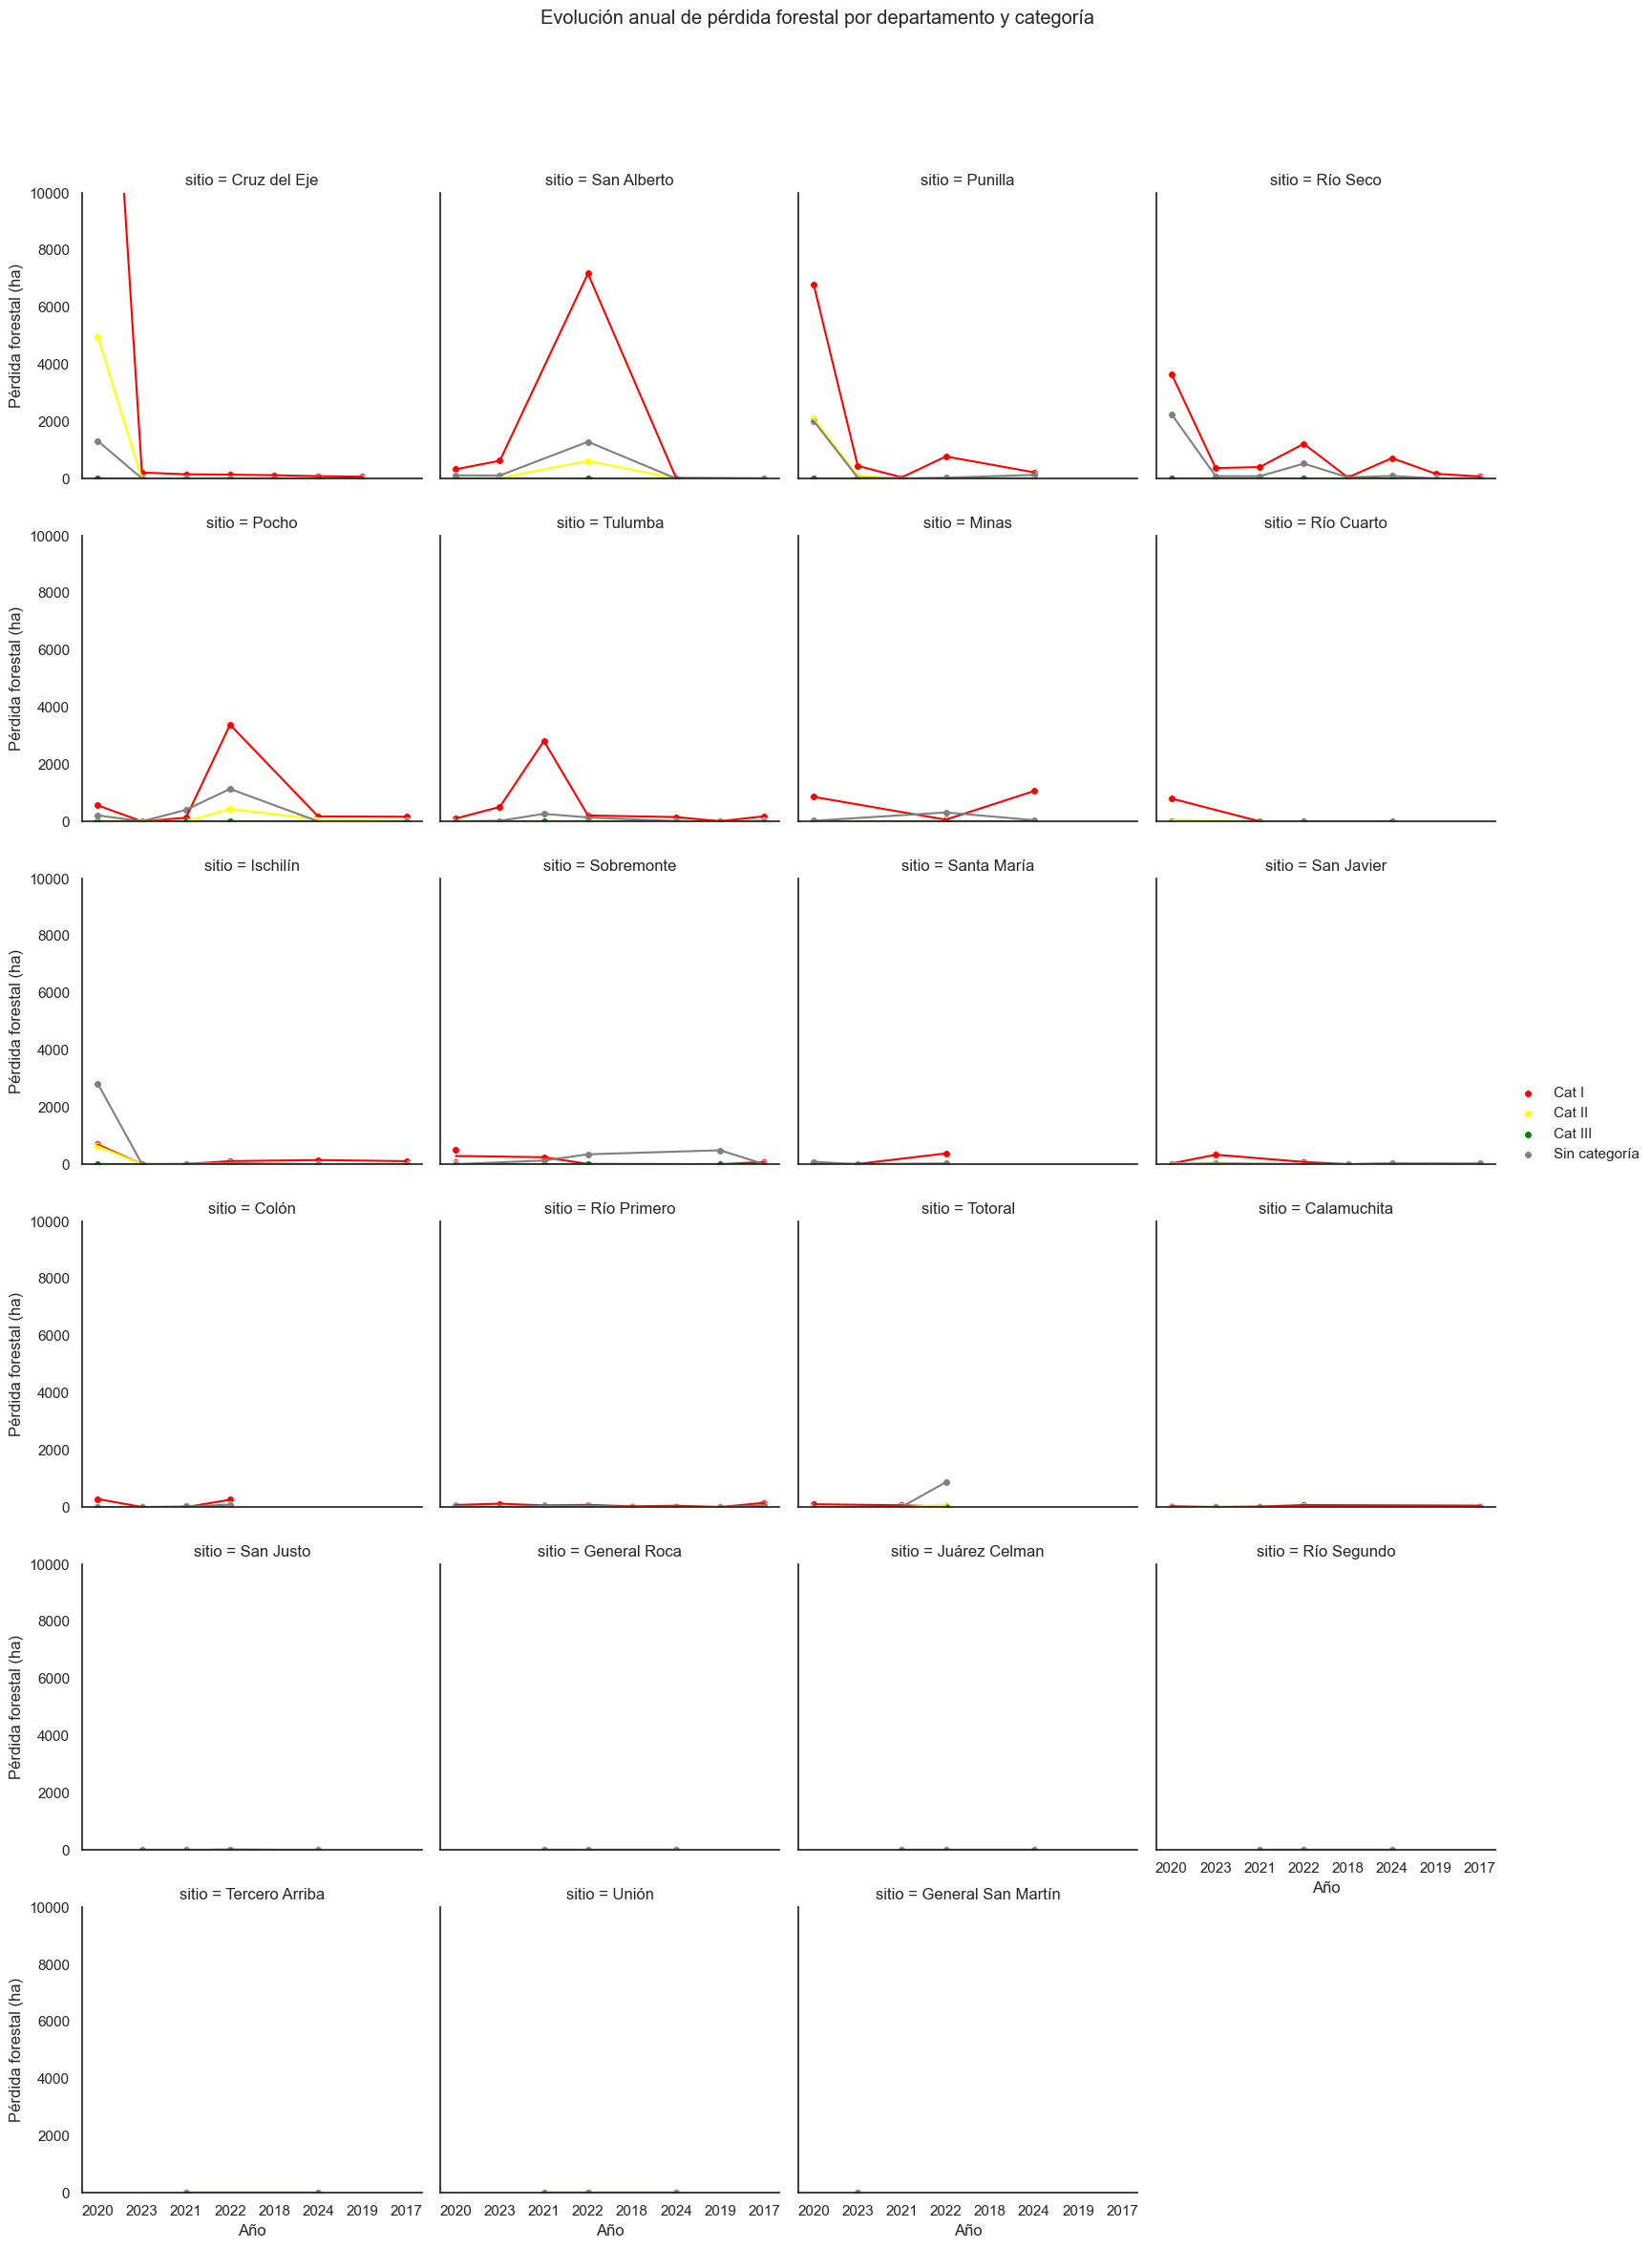

In [17]:
# 3. ANÁLISIS A ESCALA DEPARTAMENTAL

# Se filtran los registros con resolución espacial departamental
data_dpto = data[data["resolucion_espacial"] == "dpto"].copy()

print(data_dpto["sitio"].unique())
print(data_dpto.columns)

data_dpto["sitio"] = data_dpto["sitio"].str.strip()

data_dpto["sitio"] = data_dpto["sitio"].replace({
    "Rio Primero": "Río Primero",
    "Rio Seco": "Río Seco",
    "Santa Maria": "Santa María",
    "Gral. San Martín": "General San Martín"
})

# Hay un error en las columnas que hay un espacio con esto lo eliminamos
data_dpto.columns = data_dpto.columns.str.strip()
print(sorted(data["sitio"].unique()))

# 3.1 Transformación a formato largo (idéntica lógica que escala provincial)


data_long_dpto = data_dpto.melt(
    id_vars=[col for col in data_dpto.columns if col not in cols_categorias],
    value_vars=cols_categorias,
    var_name="categoria",
    value_name="hectareas"
)

data_long_dpto["categoria"] = data_long_dpto["categoria"].replace({
    "perdida_forestales_otras_cat_I": "Cat I",
    "perdida_forestales_otras_cat_II": "Cat II",
    "perdida_forestales_otras_cat_III": "Cat III",
    "perdida_forestales_otras_cat_Scat": "Sin categoría"
})

# 3.2 Visualización: evolución anual por departamento


g = sns.FacetGrid(
    data_long_dpto,
    col="sitio",
    col_wrap=4,
    sharey=True,
    height=4,
    hue="categoria",
    palette={
        "Cat I": "red",
        "Cat II": "yellow",
        "Cat III": "green",
        "Sin categoría": "grey"
    }
)

g.map_dataframe(sns.lineplot, x="year", y="hectareas")
g.map_dataframe(sns.scatterplot, x="year", y="hectareas", s=30)

g.set_axis_labels("Año", "Pérdida forestal (ha)")
g.add_legend(title="")

for ax in g.axes.flatten():
    ax.set_ylim(0, 10000)

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Evolución anual de pérdida forestal por departamento y categoría")

plt.show()



In [18]:

# 4. LIMPIEZA DE AÑOS CON RANGOS (EJ: 2000-2001)
#
# En algunos registros, el año aparece como rango (ej: "2000-2001").
# Este bloque:
# 1. Separa año inicial y final.
# 2. Genera una secuencia intermedia.
# 3. Expande las filas para tener un año por fila.

def expand_year_range(row):
    year_str = str(row["year"])
    if "-" in year_str:
        start, end = map(int, year_str.split("-"))
        return list(range(start, end + 1))
    else:
        return [int(year_str)]

data_provincial["year_clean"] = data_provincial.apply(expand_year_range, axis=1)

# Expandir filas
data_provincial = data_provincial.explode("year_clean")

#------------------------------------------------------------------------------


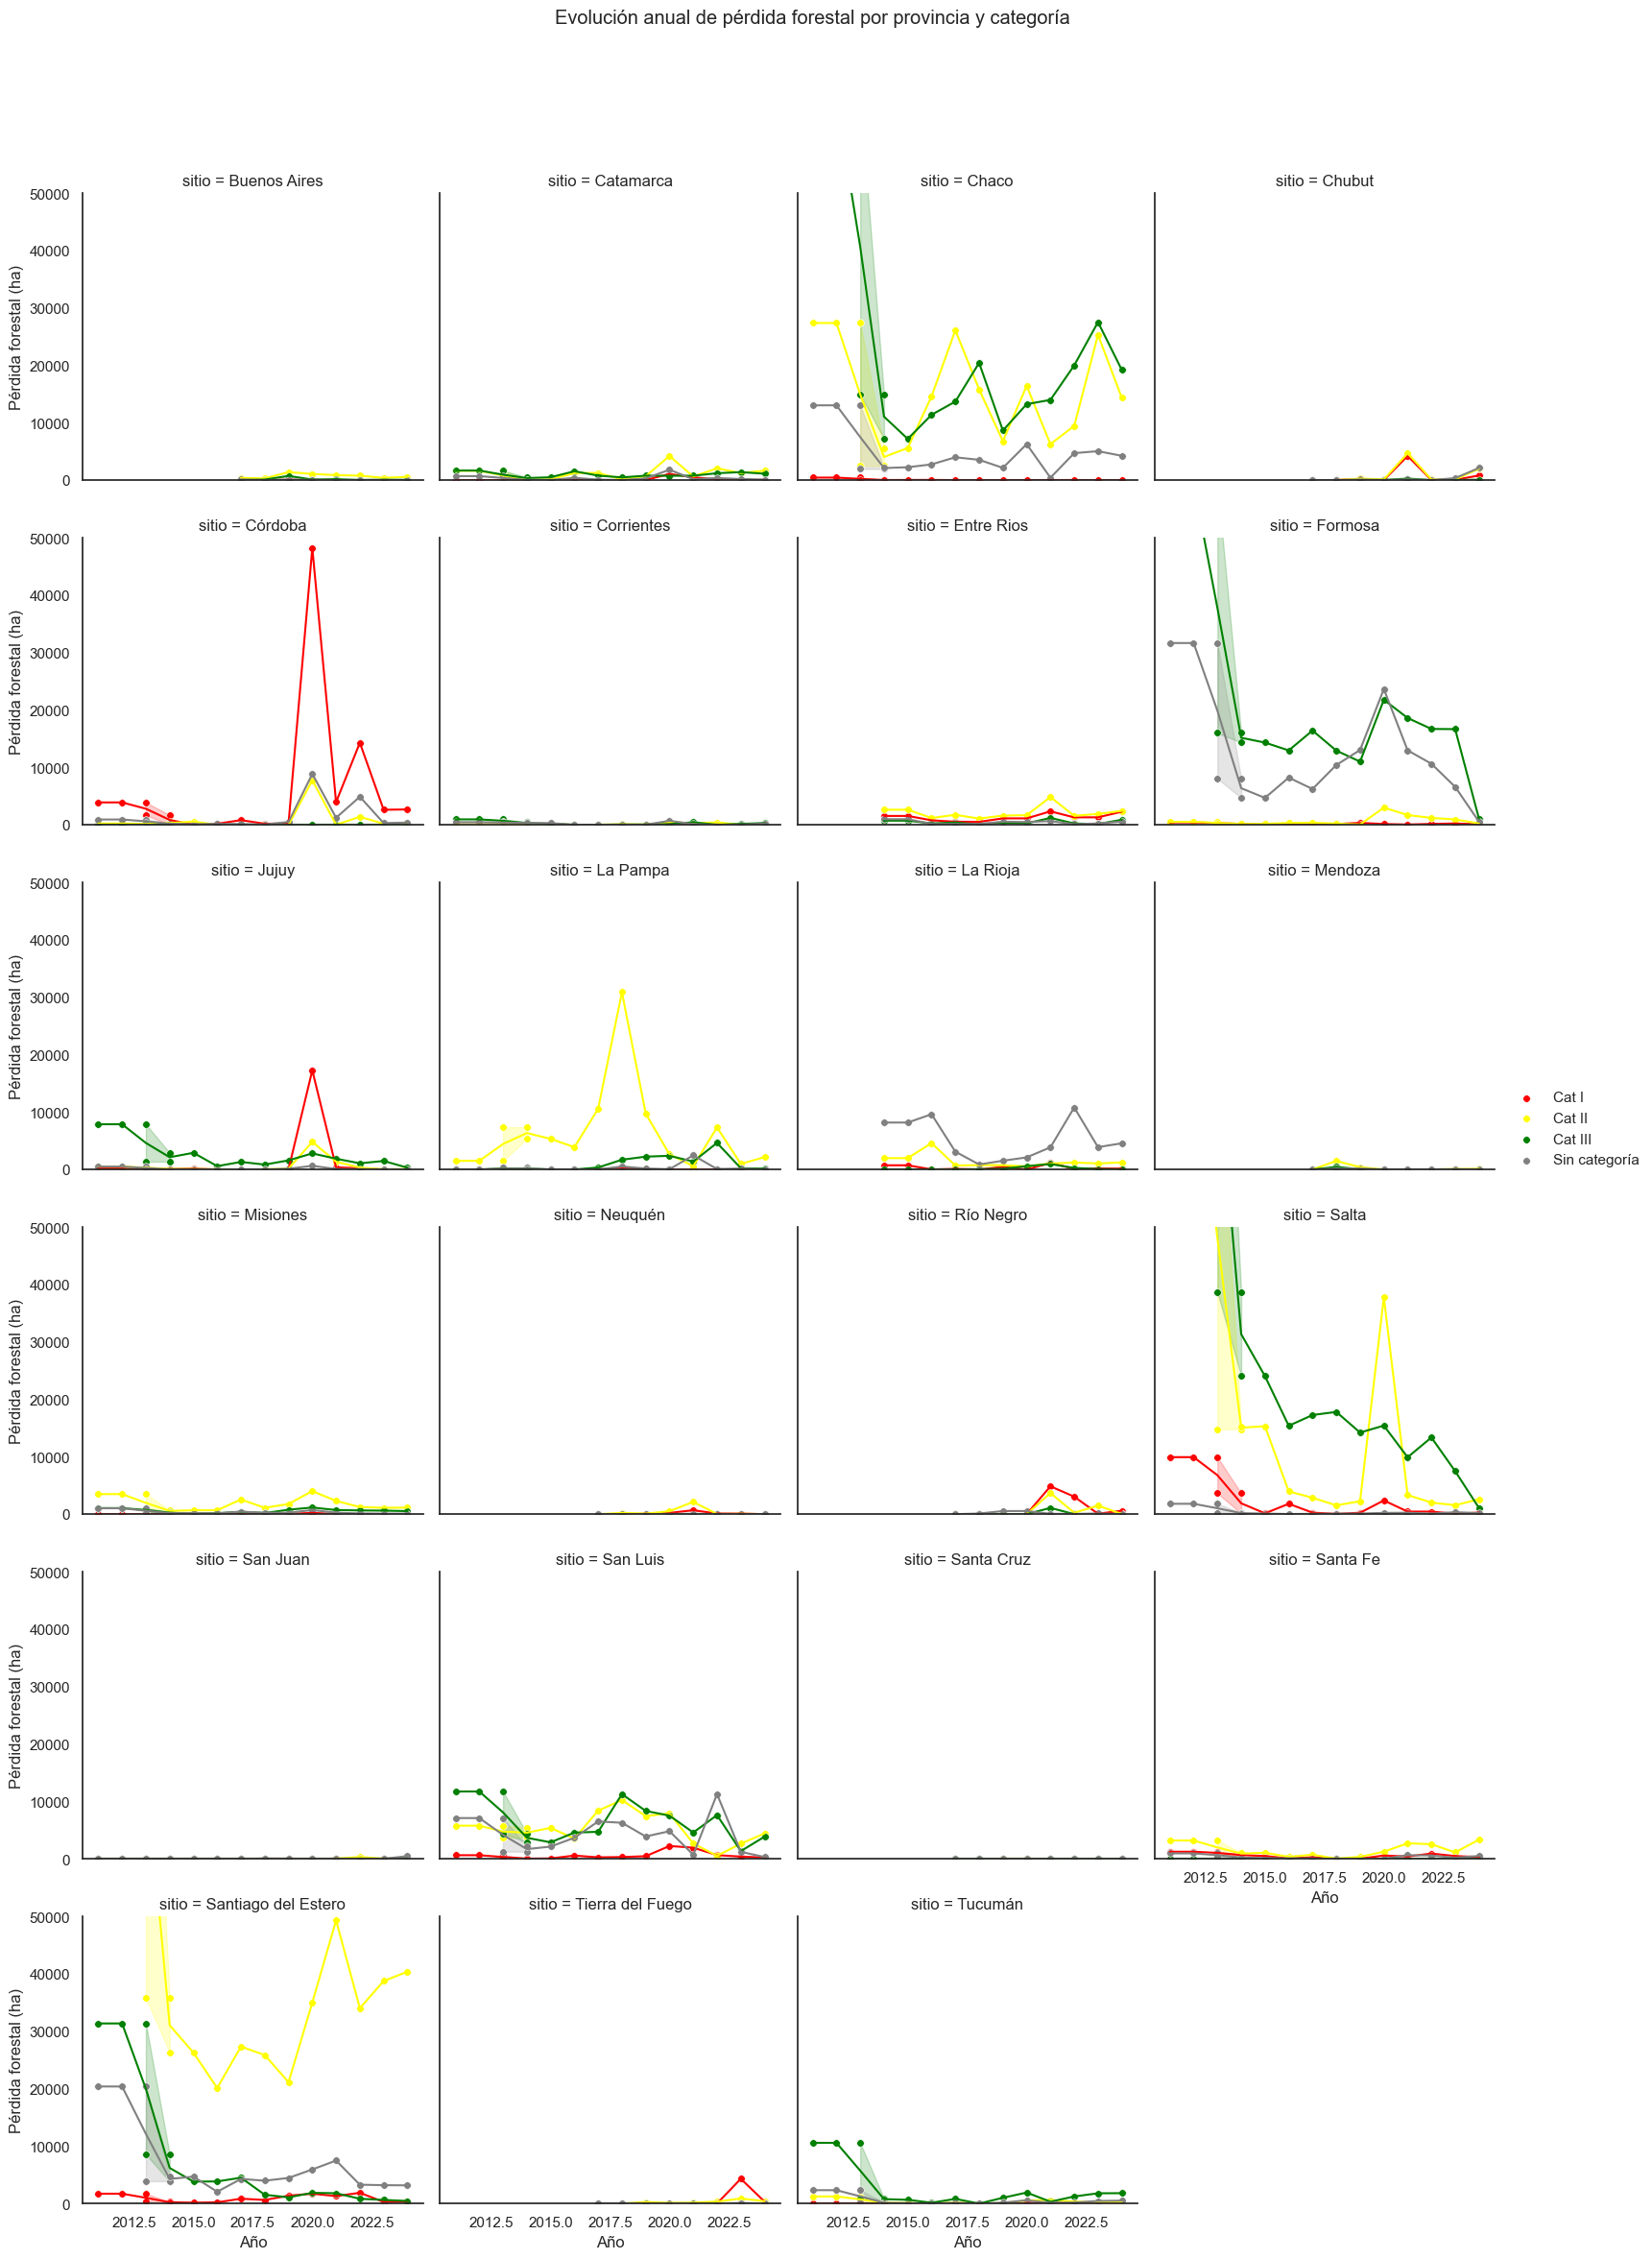

In [19]:
# Transformación nuevamente a formato largo con año limpio
data_long = data_provincial.melt(
    id_vars=[col for col in data_provincial.columns if col not in cols_categorias],
    value_vars=cols_categorias,
    var_name="categoria",
    value_name="hectareas"
)

data_long["categoria"] = data_long["categoria"].replace({
    "perdida_forestales_otras_cat_I": "Cat I",
    "perdida_forestales_otras_cat_II": "Cat II",
    "perdida_forestales_otras_cat_III": "Cat III",
    "perdida_forestales_otras_cat_Scat": "Sin categoría"
})

#------------------------------------------------------------------------------
# Visualización final con año expandido


g = sns.FacetGrid(
    data_long,
    col="sitio",
    col_wrap=4,
    sharey=True,
    height=4,
    hue="categoria",
    palette={
        "Cat I": "red",
        "Cat II": "yellow",
        "Cat III": "green",
        "Sin categoría": "grey"
    }
)

g.map_dataframe(sns.lineplot, x="year_clean", y="hectareas")
g.map_dataframe(sns.scatterplot, x="year_clean", y="hectareas", s=30)

g.set_axis_labels("Año", "Pérdida forestal (ha)")
g.add_legend(title="")

for ax in g.axes.flatten():
    ax.set_ylim(0, 50000)

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Evolución anual de pérdida forestal por provincia y categoría")

plt.show()